In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [ ]:
function meshgrid(x, y)
    X = repeat(x', length(y), 1)
    Y = repeat(y, 1, length(x))
    return X, Y
end

In [4]:
fixed_source = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :isSource => Bool, 
        :S => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64,

        :sigma => Float64 #Gaussian width. 
    ),

    # medium = Dict(
    #     :mm => Float64
    # ),

    agentODE = quote  

        # R_source = 0.0
        # R_source = 1.0  # μm — size of source
        R_source = 2.0
        # R_source = 5.0
        # R_source = 10.0
        # R_source = 20.0

        r = sqrt((x)^2 + (y)^2)

        mm = max(0.0, exp(-((r - R_source)^2) / (2 * sigma^2)))   #Gaussian gradient
        # mm = 1.0 * exp(-max(0.0, r - R_source) / 10.0)   -- exponential gradient
        # mm = 10.0 * exp(-max(0.0, r - R_source) / 10.0)
        # mm = 100.0 * exp(-max(0.0, r - R_source) / 10.0)

        # r = sqrt((x - 0.3)^2 + (y - 0.3)^2)
        # mm = 1 * exp(-r / 10.0)
        M = mm

        F = ε0 + ε1 * methyl + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) #Equació del paper per definir activitat del receptor
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)        #Energia lliure en estat adaptat

        mx = (ε0 + Nrec * log((1 + mm / Ki) / (1 + mm / Ka)) - F0) / (- ε1)

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = active * vx  #Change position acording to constant speed afected by forces
        dt(y) = active * vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote
        if isSource
            active = false
            x = 0
            y = 0
            vx = 0.0
            vy = 0.0
            # mm += S  
        else

            v_run = v
            v_tumble = 0.25 

            speed = active ? v_run : v_tumble

            Dr_tumble = 6.2      
            Dr_total = active ? Dr_run : Dr_tumble

            if active 
                λ = ωFrec*exp(-G)
                P = 1 - exp(-λ * dt)
                
            else
                λ = ωFrec*exp(G)
                P = 1 - exp(-λ * dt)  
                
            end


            if active 
                λrt = ωFrec*exp(-G) 

                P_rt = 1 - exp(-λrt * dt)
                P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
                else     #Si rate baixa 
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
                end

            else
                λtr = ωFrec*exp(G) 
                P_tr = 1 - exp(-λtr * dt)
                P = rand()

                if P < P_tr
                    active = true
                    vx = speed * cos(theta)
                    vy = speed * sin(theta)
                    theta += sqrt(2 * Dr_total * dt) * randn()
                else
                    active = false
                    vx = speed
                    vy = speed
                    theta += sqrt(2 * Dr_total * dt) * randn()
                end
            end

        end

        if x < simBox[1,1]*0.9
            x = simBox[1,1]*0.9
            theta = pi - theta   
        elseif x > simBox[1,2]*0.9
            x = simBox[1,2]*0.9
            theta = pi - theta
        end
        if y < simBox[2,1]*0.9
            y = simBox[2,1]*0.9
            theta = -theta/2
        elseif y > simBox[2,2]*0.9
            y = simBox[2,2]*0.9
            theta = -theta/2
        end

    end,
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	isSource (Bool agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	sigma (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)


UPDATE RULES
agentRule
 begin
    if isSource
        active__ = false
        x__ = 0
        y__ = 0
    

In [87]:
com = Community(
    fixed_source,
    N=21,
    dt=0.01,
    # dt=0.01,
    # simBox = [-20.0 20.0; -20.0 20.0],
    # simBox = [-50.0 50.0; -50.0 50.0],
    # simBox = [-100.0 100.0; -100.0 100.0],
    simBox = [-500.0 500.0; -500.0 500.0],
    # NMedium = [250, 250]
    NMedium = [100, 100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

# com.DMedium = 1
# com.DMedium = 0.01
# com.DMedium = 0.001
# com.DMedium = 0.0001

# com.delta = 0.001

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

# com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

src = 1

com.x[src] = 0
com.y[src] = 0

com.isSource .= false
com.isSource[src] = true

com.active .= true 
com.active[src] = false   

com.S .= 0.0

# com.sigma = 1
# com.sigma = 10
com.sigma = 100

# com.S[src] = 10
# com.S[src] = 0.03
# com.S[src] = 10^10
# com.S[src] = 1000


100

In [88]:
outfile = "fixed_source.jld2"
steps = 100000

loadToPlatform!(com, preallocateAgents=21)
# com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    meta = JLD2.Group(file, "meta")
    meta["N"] = com.N
    meta["NMedium"] = com.NMedium
    meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)
        g["l"] = copy(com.l)
        g["d"] = copy(com.d)
        g["active"] = copy(com.active)
        g["isSource"] = copy(com.isSource)
        g["M"] = copy(com.M)
        g["F"] = copy(com.F)
        g["A"] = copy(com.A)
        g["λ"] = copy(com.λ)
        g["Yp"] = copy(com.Yp)
        g["methyl"] = copy(com.methyl)
        g["P"] = copy(com.P)

        # Medium grid (saved once per step)
        # g["mm_grid"] = copy(com.mm)
    end
end


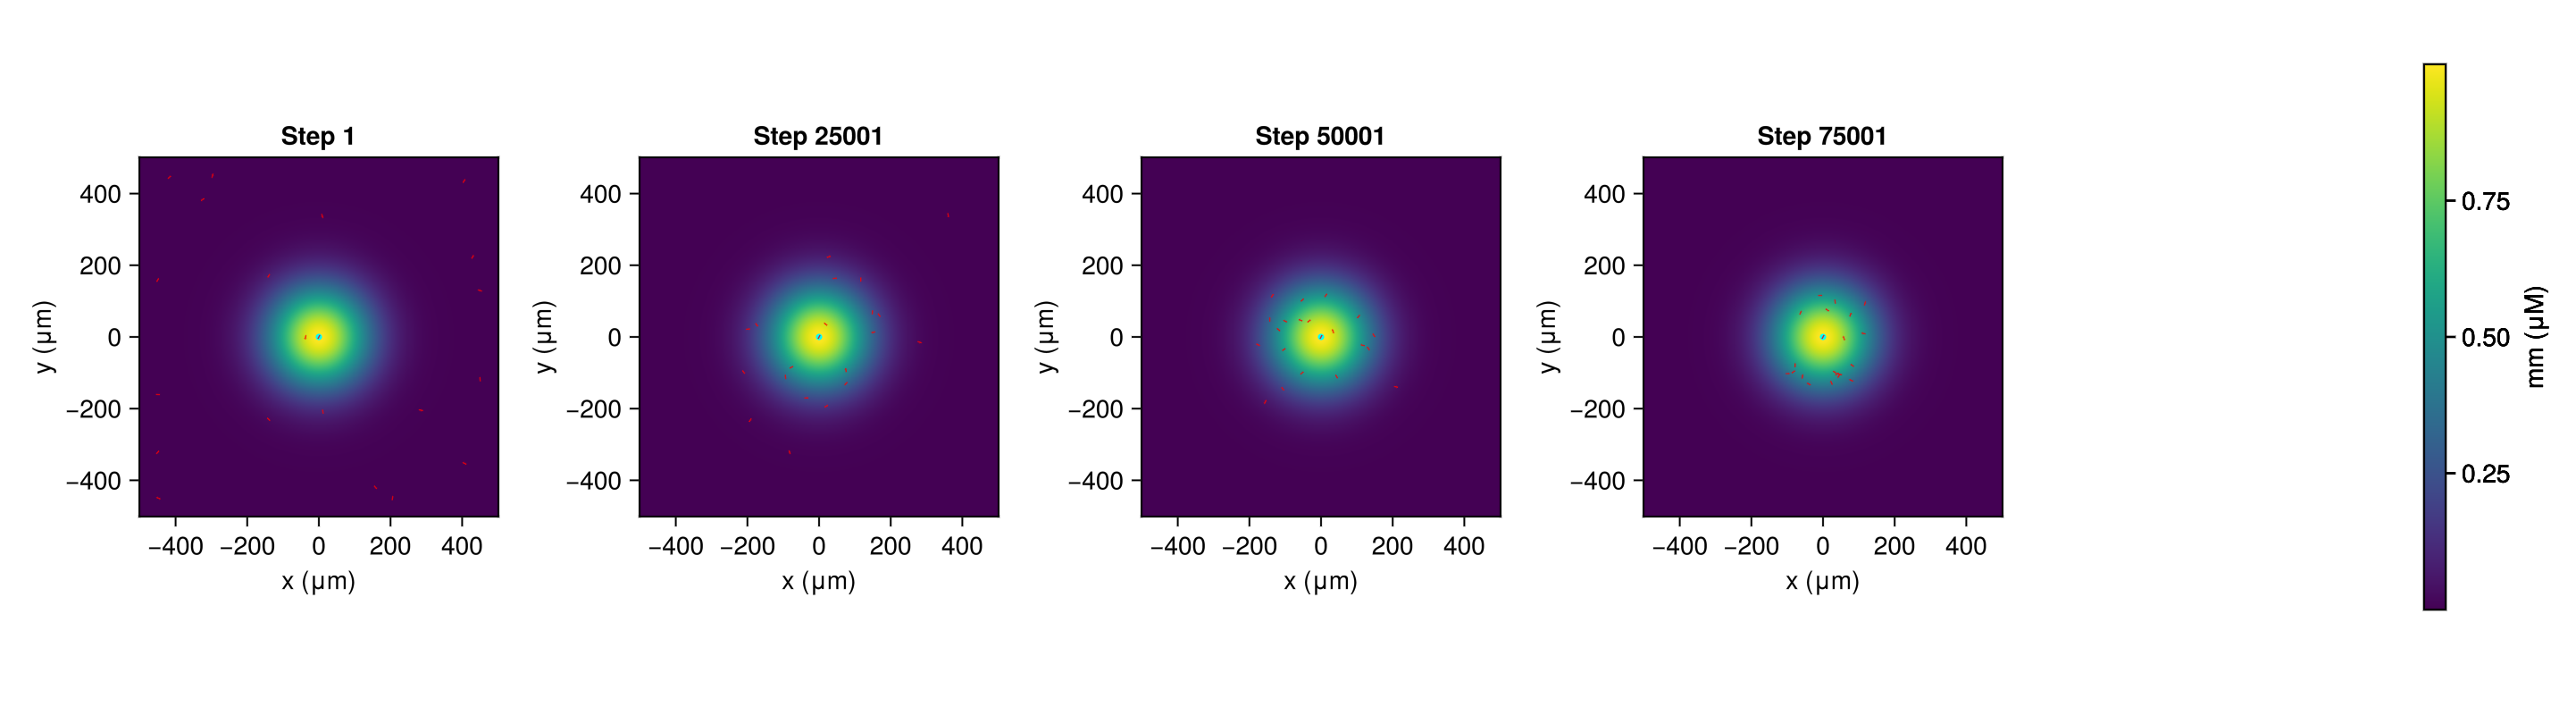

GLMakie.Screen(...)

In [90]:
fig2 = Figure(size=(2100,400))

model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]

xs, ys = 0.0, 0.0
R_source = 2.0
sigma = 100
# sigma = 10

x_grid = range(-500, 500, length=400)
# x_grid = range(-100, 100, length=200)
# x_grid = range(-50, 50, length=100)
y_grid = range(-500, 500, length=400)
# y_grid = range(-50, 50, length=100)
# y_grid = range(-100, 100, length=200)
X, Y = meshgrid(x_grid, y_grid)

mm_grid = @. 1.0 * exp(-max(0.0, sqrt(((X - xs)^2 + (Y - ys)^2)^2) - R_source) / (2 * sigma^2))

empty!(ax)
jldopen("fixed_source.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        x = Vector{Float64}(undef, 21)
        y = Vector{Float64}(undef, 21)

        ax = Axis(fig2[1, 1*j-1], aspect=1, title="Step $step",  xlabel="x (μm)", ylabel="y (μm)")

        g = file[@sprintf("step_%06d", step)]

        hm = heatmap!(ax, x_grid, y_grid, mm_grid, colormap=:viridis)
        Colorbar(fig2[1, 5], hm, label="mm (μM)")


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = g["l"]
                
        scatter!(ax, x[1], y[1], color=:cyan, markersize=5, label="Source")
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

    end
end

display(fig2)

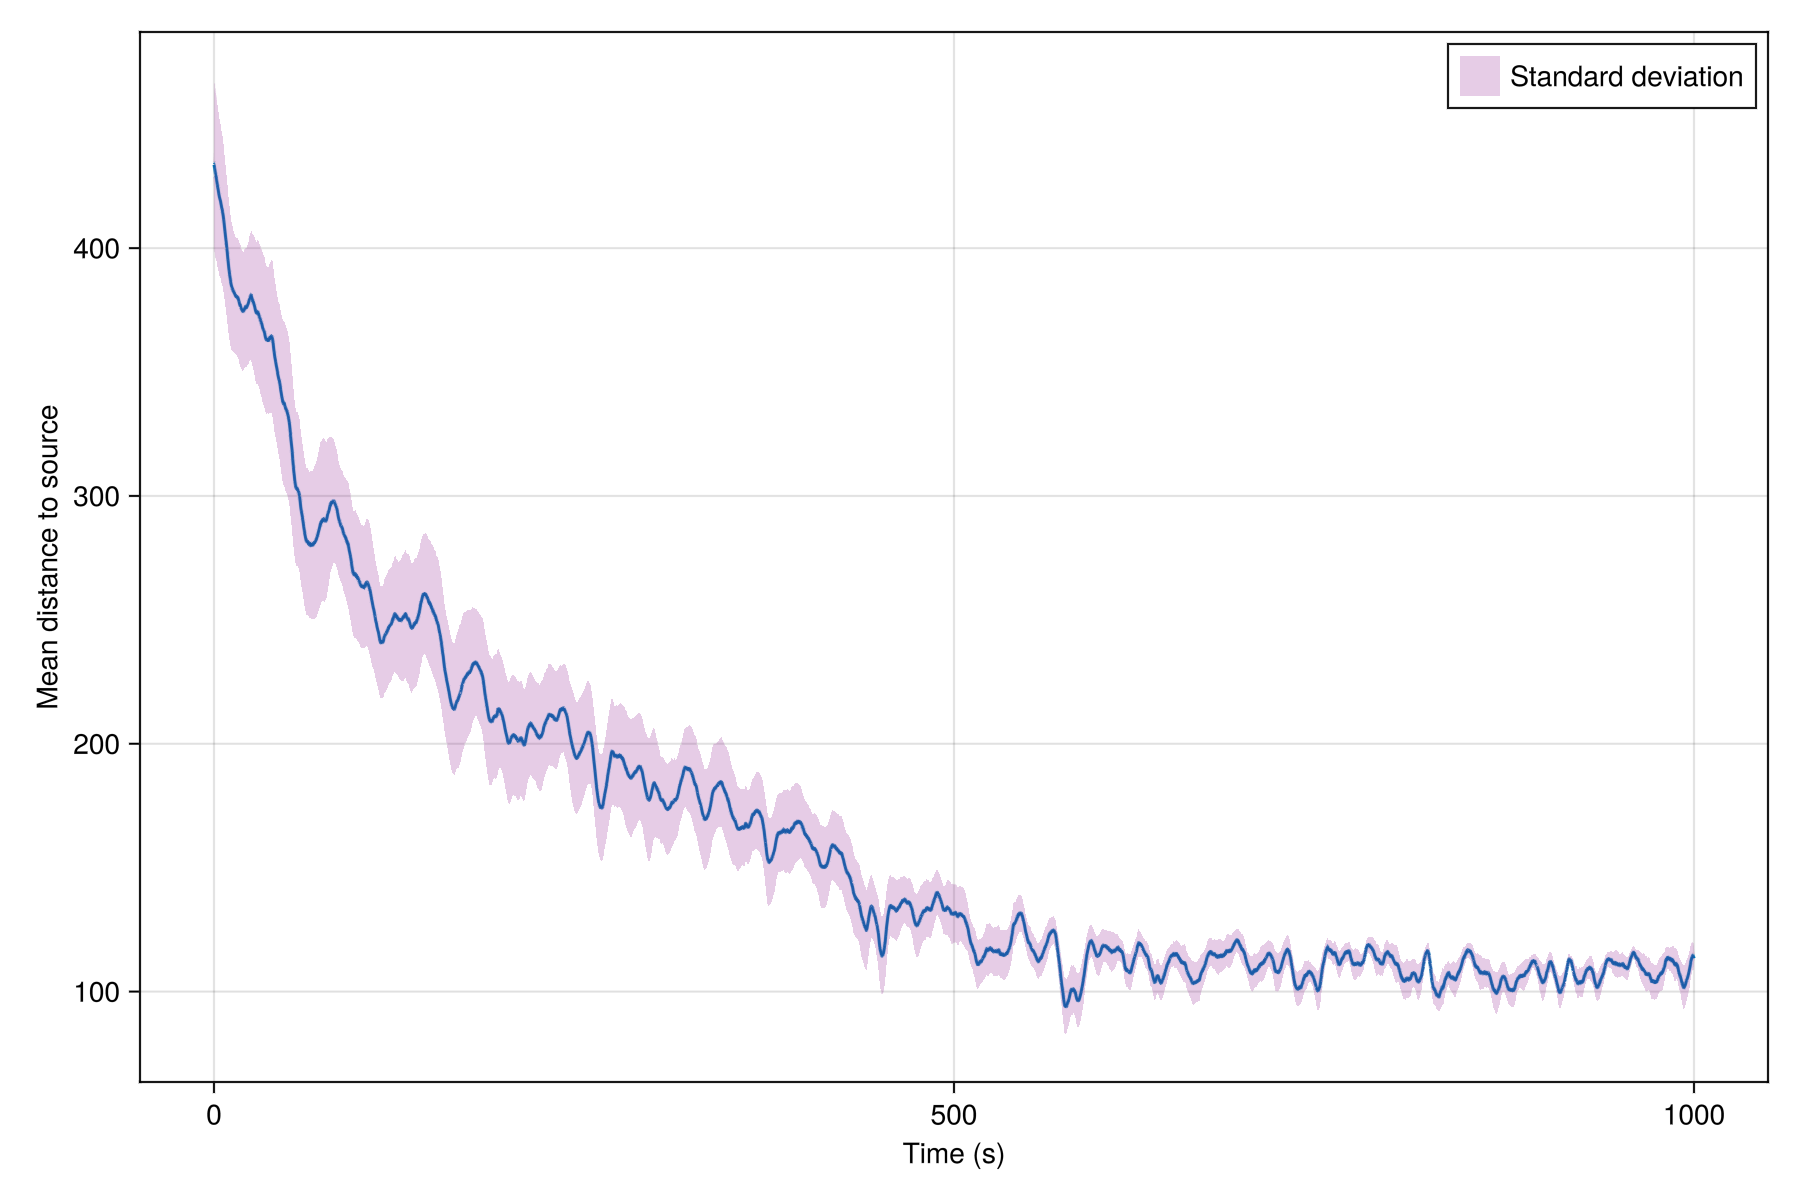

GLMakie.Screen(...)

In [91]:
fig3 = Figure(size=(900, 600))
ax1 = Axis(fig3[1,1], xlabel="Time (s)", ylabel="Mean distance to source")

mean_dist = Float64[] 
std_dist = Float64[]

jldopen("fixed_source.jld2", "r") do file 

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        src = 1

        xs = g["x"][1]
        ys = g["y"][1]

        other_x = g["x"][2:21]

        other_y = g["y"][2:21]

        dists = abs.(sqrt.((other_x .- xs).^2 .+ (other_y .- ys).^2) .- R_source)

        push!(mean_dist, mean(dists))
        push!(std_dist, std(dists))

    end

    std_dist_1 = std_dist ./ sqrt(20)

    lines!(ax1, (1:steps)*0.01, mean_dist)
    band!(ax1, (1:steps)*0.01, mean_dist .- std_dist_1, mean_dist .+ std_dist_1, color=(:purple, 0.2), label = "Standard deviation")  #Standard deviation
    # band!(ax1, (1:steps)*0.01, mean_dist .- std_dist, mean_dist .+ std_dist, color=(:yellow, 0.2), label = "Standard error")      #Standard error

    # errorbars!(ax1, (1:steps)*0.01, mean_dist, std_dist, label = "Std deviation", color = (:red, 0.2), whiskerwidth = 0.1)
end
axislegend(ax1, position =:rt)
display(fig3)

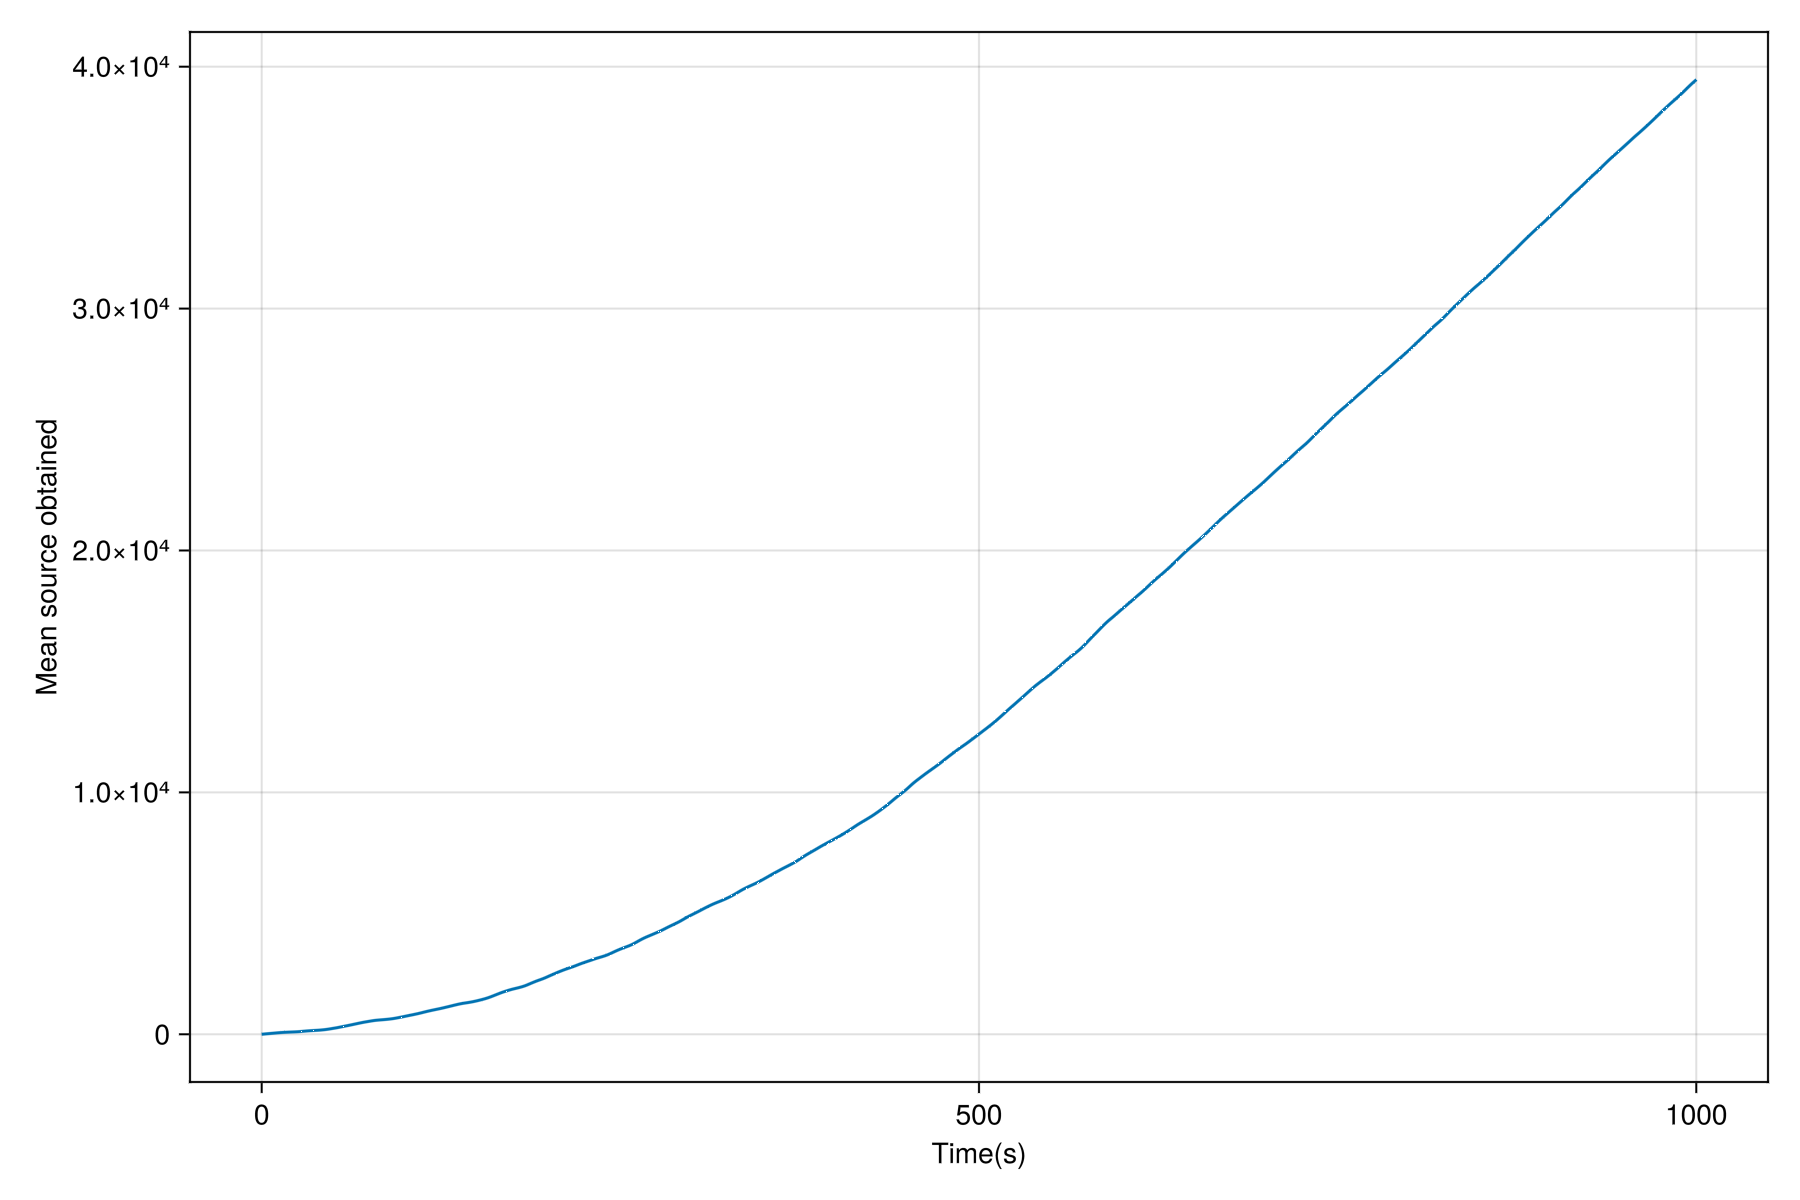

GLMakie.Screen(...)

In [92]:
fig4 = Figure(size=(900, 600))
ax1 = Axis(fig4[1,1], xlabel="Time(s)", ylabel="Mean source obtained")

mean_mm = Float64[] 
std_mm = Float64[]

jldopen("fixed_source.jld2", "r") do file 
    tot_mm = 0

    for step in 1:steps
        g = file[@sprintf("step_%06d", step)]

        mm = g["M"][2:21]
        tot_mm += mean(mm)

        push!(mean_mm, tot_mm)
        push!(std_mm, std(mm))

    end

    lines!(ax1, (1:steps)*0.01, mean_mm)
    band!(ax1, (1:steps)*0.01, mean_mm .- std_mm, mean_mm .+ std_mm, color=(:purple, 0.2))
end
display(fig4)